# Dự đoán tỷ lệ khách hàng rời bỏ với CatBoost

Notebook này triển khai một pipeline học máy để dự đoán tỷ lệ khách hàng rời bỏ bằng cách sử dụng **CatBoost** với các kỹ thuật kỹ thuật đặc trưng nâng cao, bao gồm:
- **Siêu tham số được tối ưu hóa bằng Optuna**: Các tham số được tinh chỉnh thông qua tối ưu hóa Bayes
- **Đặc trưng phân loại tổng hợp Bi-gram và Tri-gram**: Ghép nối các cặp/bộ ba đặc trưng phân loại hàng đầu
- **Mã hóa mục tiêu K-fold bên trong**: Mã hóa các đặc trưng phân loại bằng cách sử dụng thống kê mục tiêu
- **Kỹ thuật đặc trưng toàn diện**: Mã hóa tần số, tương tác số học, số lượng dịch vụ, đặc trưng phân phối và đặc trưng cấp chữ số

## 2. Mô tả và Tải Tập Dữ Liệu

### Nguồn Dữ Liệu
- **Tập Huấn Luyện**: Dữ liệu khách hàng đã được gắn nhãn để huấn luyện mô hình
- **Tập Kiểm Tra**: Dữ liệu chưa được gắn nhãn để gửi dự đoán
- **Tập Dữ Liệu Gốc**: Dữ liệu lịch sử bổ sung từ WA_Fn-UseC_-Telco-Customer-Churn.csv

### Tổng Quan Các Tính Năng
| Danh Mục | Tính Năng | Mô Tả |
|----------|----------|-------------|
| **Thông Tin Nhân Khẩu Học** | Giới tính, Người Cao Tuổi, Đối Tác, Người Phụ Thuộc | Thông tin hồ sơ khách hàng |
| **Dịch Vụ** | Dịch Vụ Điện Thoại, Nhiều Đường Dây, Dịch Vụ Internet, Bảo Mật Trực Tuyến, Sao Lưu Trực Tuyến, Bảo Vệ Thiết Bị, Hỗ Trợ Kỹ Thuật, Truyền Hình Trực Tuyến, Phim Trực Tuyến | Các dịch vụ đã đăng ký |
| **Tài Khoản** | Thời hạn sử dụng, Hợp Đồng, Hóa Đơn Điện Tử, Phương Thức Thanh Toán, Phí Hàng Tháng, Tổng Phí | Thông tin tài khoản và hóa đơn |
| **Mục Tiêu** | Tỷ lệ khách hàng rời bỏ | Khách hàng đã rời đi (Có/Không) |

In [ ]:
import numpy as np
import pandas as pd
import warnings
import gc
import time
from itertools import combinations

from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder, LabelEncoder
from catboost import CatBoostClassifier, Pool

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✓ All libraries loaded successfully!")

✓ All libraries loaded successfully!


In [ ]:
# Configuration
class CFG:
    """Configuration class for experiment settings"""
    EXP_NAME = "CatBoost_Optuna_Churn"
    TARGET = 'Churn'
    N_FOLDS = 20       # bên ngoài CV folds
    INNER_FOLDS = 5    # bên trong CV folds vì target encoding
    RANDOM_SEED = 42
    

    TRAIN_PATH = "/kaggle/input/competitions/playground-series-s6e3/train.csv"
    TEST_PATH = "/kaggle/input/competitions/playground-series-s6e3/test.csv"
    ORIGINAL_PATH = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Các nhóm phân loại hàng đầu cho các tổ hợp bigram/trigram (theo tầm quan trọng của đặc trưng)
TOP_CATS_FOR_NGRAM = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

# CatBoost Parameters (Optuna-Optimized)
CAT_PARAMS = {
    'iterations': 20000,
    'learning_rate': 0.00984,
    'depth': 7,
    'l2_leaf_reg': 5.333,
    'random_strength': 2.877,
    'bagging_temperature': 0.264,
    'border_count': 254,
    'min_data_in_leaf': 14,
    'grow_policy': 'SymmetricTree',
    'random_seed': CFG.RANDOM_SEED,
    'early_stopping_rounds': 200,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'GPU',
    'devices': '0',
    'verbose': 0,
    'use_best_model': True,
}

print("✓ Configuration set!")

✓ Configuration set!


###  Kết quả tối ưu hóa Optuna

<div style="background: linear-gradient(135deg, #fff7ed 0%, #ffedd5 100%);

padding: 20px;

border-radius: 12px;

border-left: 5px solid #f97316;

margin: 15px 0;">

<h4 style="margin-top:0; color:#9a3412;">Kết quả tìm kiếm siêu tham số</h4>

<p style="color:#7c2d12;">
Các tham số sau đã được tối ưu hóa bằng cách sử dụng <strong>bộ lấy mẫu TPE của Optuna</strong> với
<strong>phương pháp kiểm định chéo 5 lần</strong>.
</p>

<table style="width:100%; border-collapse: collapse; background:white; border-radius:8px; overflow:hidden;">
<thead>
<tr style="background:#fed7aa;">
<th style="padding:8px; text-align:left;">Tham số</th>
<th style="padding:8px; text-align:left;">Giá trị tối ưu</th>
<th style="padding:8px; text-align:left;">Phạm vi tìm kiếm</th>
</tr>
</thead>
<tbody>
<tr><td>Tốc độ học</td><td>0.00984</td><td>[0.001, 0.1]</td></tr>
<tr><td>Độ sâu</td><td>7</td><td>[4, 10]</td></tr>
<tr><td>l2_leaf_reg</td><td>5.333</td><td>[0.1, 10]</td></tr>
<tr><td>random_strength</td><td>2.877</td><td>[0, 10]</td></tr>
<tr><td>bagging_temperature</td><td>0.264</td><td>[0, 1]</td></tr>
<tr><td>border_count</td><td>254</td><td>[32, 255]</td></tr>
<tr><td>min_data_in_leaf</td><td>14</td><td>[1, 50]</td></tr>
<tr><td>grow_policy</td><td>SymmetricTree</td><td>[SymmetricTree, Depthwise, Lossguide]</td></tr>
</tbody>

</table>

</p>

</div>

In [ ]:

print("Loading datasets...")
train = pd.read_csv(CFG.TRAIN_PATH)
test = pd.read_csv(CFG.TEST_PATH)
orig = pd.read_csv(CFG.ORIGINAL_PATH)

# Mã hóa biến mục tiêu
train[CFG.TARGET] = train[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)
orig[CFG.TARGET] = orig[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)

# Xử lý TotalCharges trong dữ liệu gốc
orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
orig['TotalCharges'].fillna(orig['TotalCharges'].median(), inplace=True)

# Xóa ID khách hàng nếu có
if 'customerID' in orig.columns:
    orig.drop(columns=['customerID'], inplace=True)

# Lưu ID để sử dụng sau này
train_ids = train['id'].copy()
test_ids = test['id'].copy()

print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")
print(f"Original Shape: {orig.shape}")

Loading datasets...
Train Shape : (594194, 21)
Test Shape  : (254655, 20)
Original Shape: (7043, 20)



## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Dataset Overview
print("="*60)
print("TRAINING DATA OVERVIEW")
print("="*60)
display(train.head())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(train.dtypes.to_frame('dtype'))

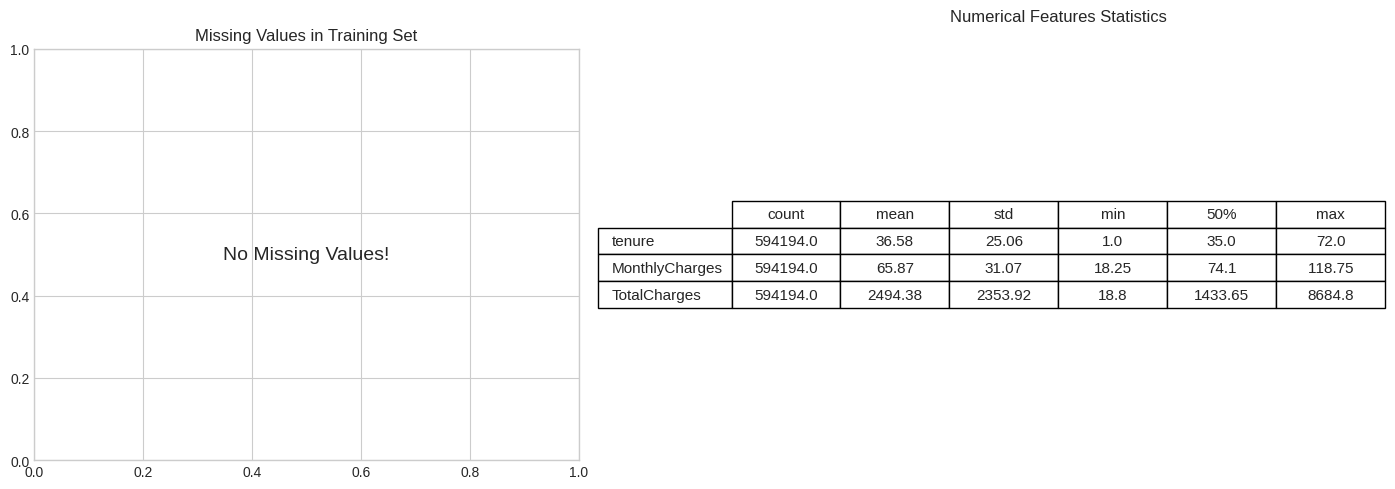

In [ ]:
# Phân tích giá trị thiếu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Giá trị thiếu trong tập dữ liệu huấn luyện
train_missing = train.isnull().sum()
train_missing = train_missing[train_missing > 0]
if len(train_missing) > 0:
    axes[0].barh(train_missing.index, train_missing.values, color='#f97316')
    axes[0].set_xlabel('Missing Count')
    axes[0].set_title('Missing Values in Training Set')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values!', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values in Training Set')

# Thống kê số liệu
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
stats_df = train[num_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
axes[1].axis('off')
table = axes[1].table(cellText=stats_df.round(2).values,
                       rowLabels=stats_df.index,
                       colLabels=stats_df.columns,
                       cellLoc='center',
                       loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
axes[1].set_title('Numerical Features Statistics', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

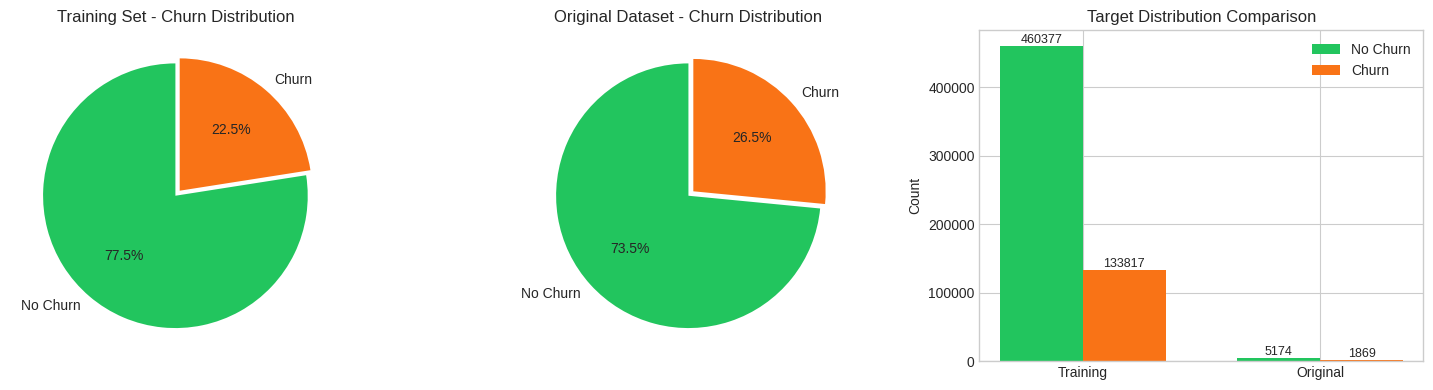


Churn Rate - Training: 22.52%
Churn Rate - Original: 26.54%


In [ ]:
# Phân phối mục tiêu
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mục tiêu của tập huấn luyện
train_churn = train[CFG.TARGET].value_counts()
colors = ['#22c55e', '#f97316']
axes[0].pie(train_churn.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[0].set_title('Training Set - Churn Distribution')

# Mục tiêu của tập dữ liệu gốc
orig_churn = orig[CFG.TARGET].value_counts()
axes[1].pie(orig_churn.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title('Original Dataset - Churn Distribution')

# Biểu đồ so sánh
x = np.arange(2)
width = 0.35
bars1 = axes[2].bar(x - width/2, [train_churn[0], orig_churn[0]], width, label='No Churn', color='#22c55e')
bars2 = axes[2].bar(x + width/2, [train_churn[1], orig_churn[1]], width, label='Churn', color='#f97316')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Training', 'Original'])
axes[2].set_ylabel('Count')
axes[2].set_title('Target Distribution Comparison')
axes[2].legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[2].annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nChurn Rate - Training: {train[CFG.TARGET].mean()*100:.2f}%")
print(f"Churn Rate - Original: {orig[CFG.TARGET].mean()*100:.2f}%")

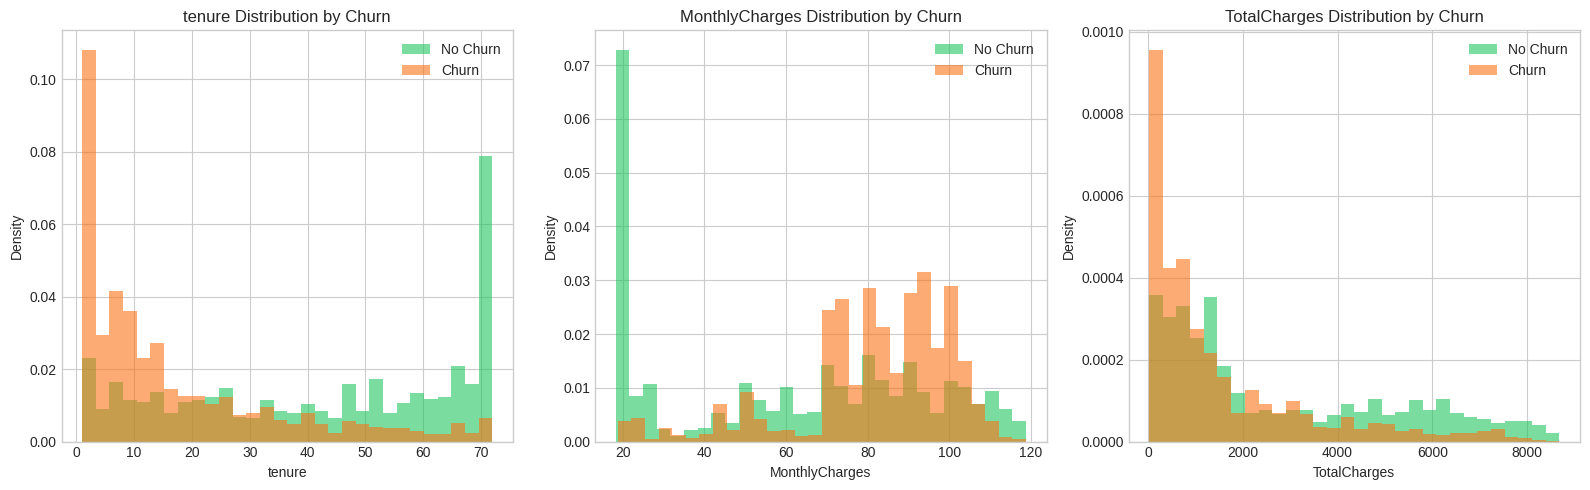


Key Observations:
  - Tenure: Churners tend to have shorter tenure
  - MonthlyCharges: Churners often have higher monthly charges
  - TotalCharges: Churners typically have lower total charges (correlated with tenure)


In [ ]:
# Phân bố các đặc điểm số theo tỷ lệ khách hàng rời bỏ
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    for churn_val, label, color in [(0, 'No Churn', '#22c55e'), (1, 'Churn', '#f97316')]:
        data = train[train[CFG.TARGET] == churn_val][col]
        axes[idx].hist(data, bins=30, alpha=0.6, label=label, color=color, density=True)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'{col} Distribution by Churn')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("  - Tenure: Churners tend to have shorter tenure")
print("  - MonthlyCharges: Churners often have higher monthly charges")
print("  - TotalCharges: Churners typically have lower total charges (correlated with tenure)")

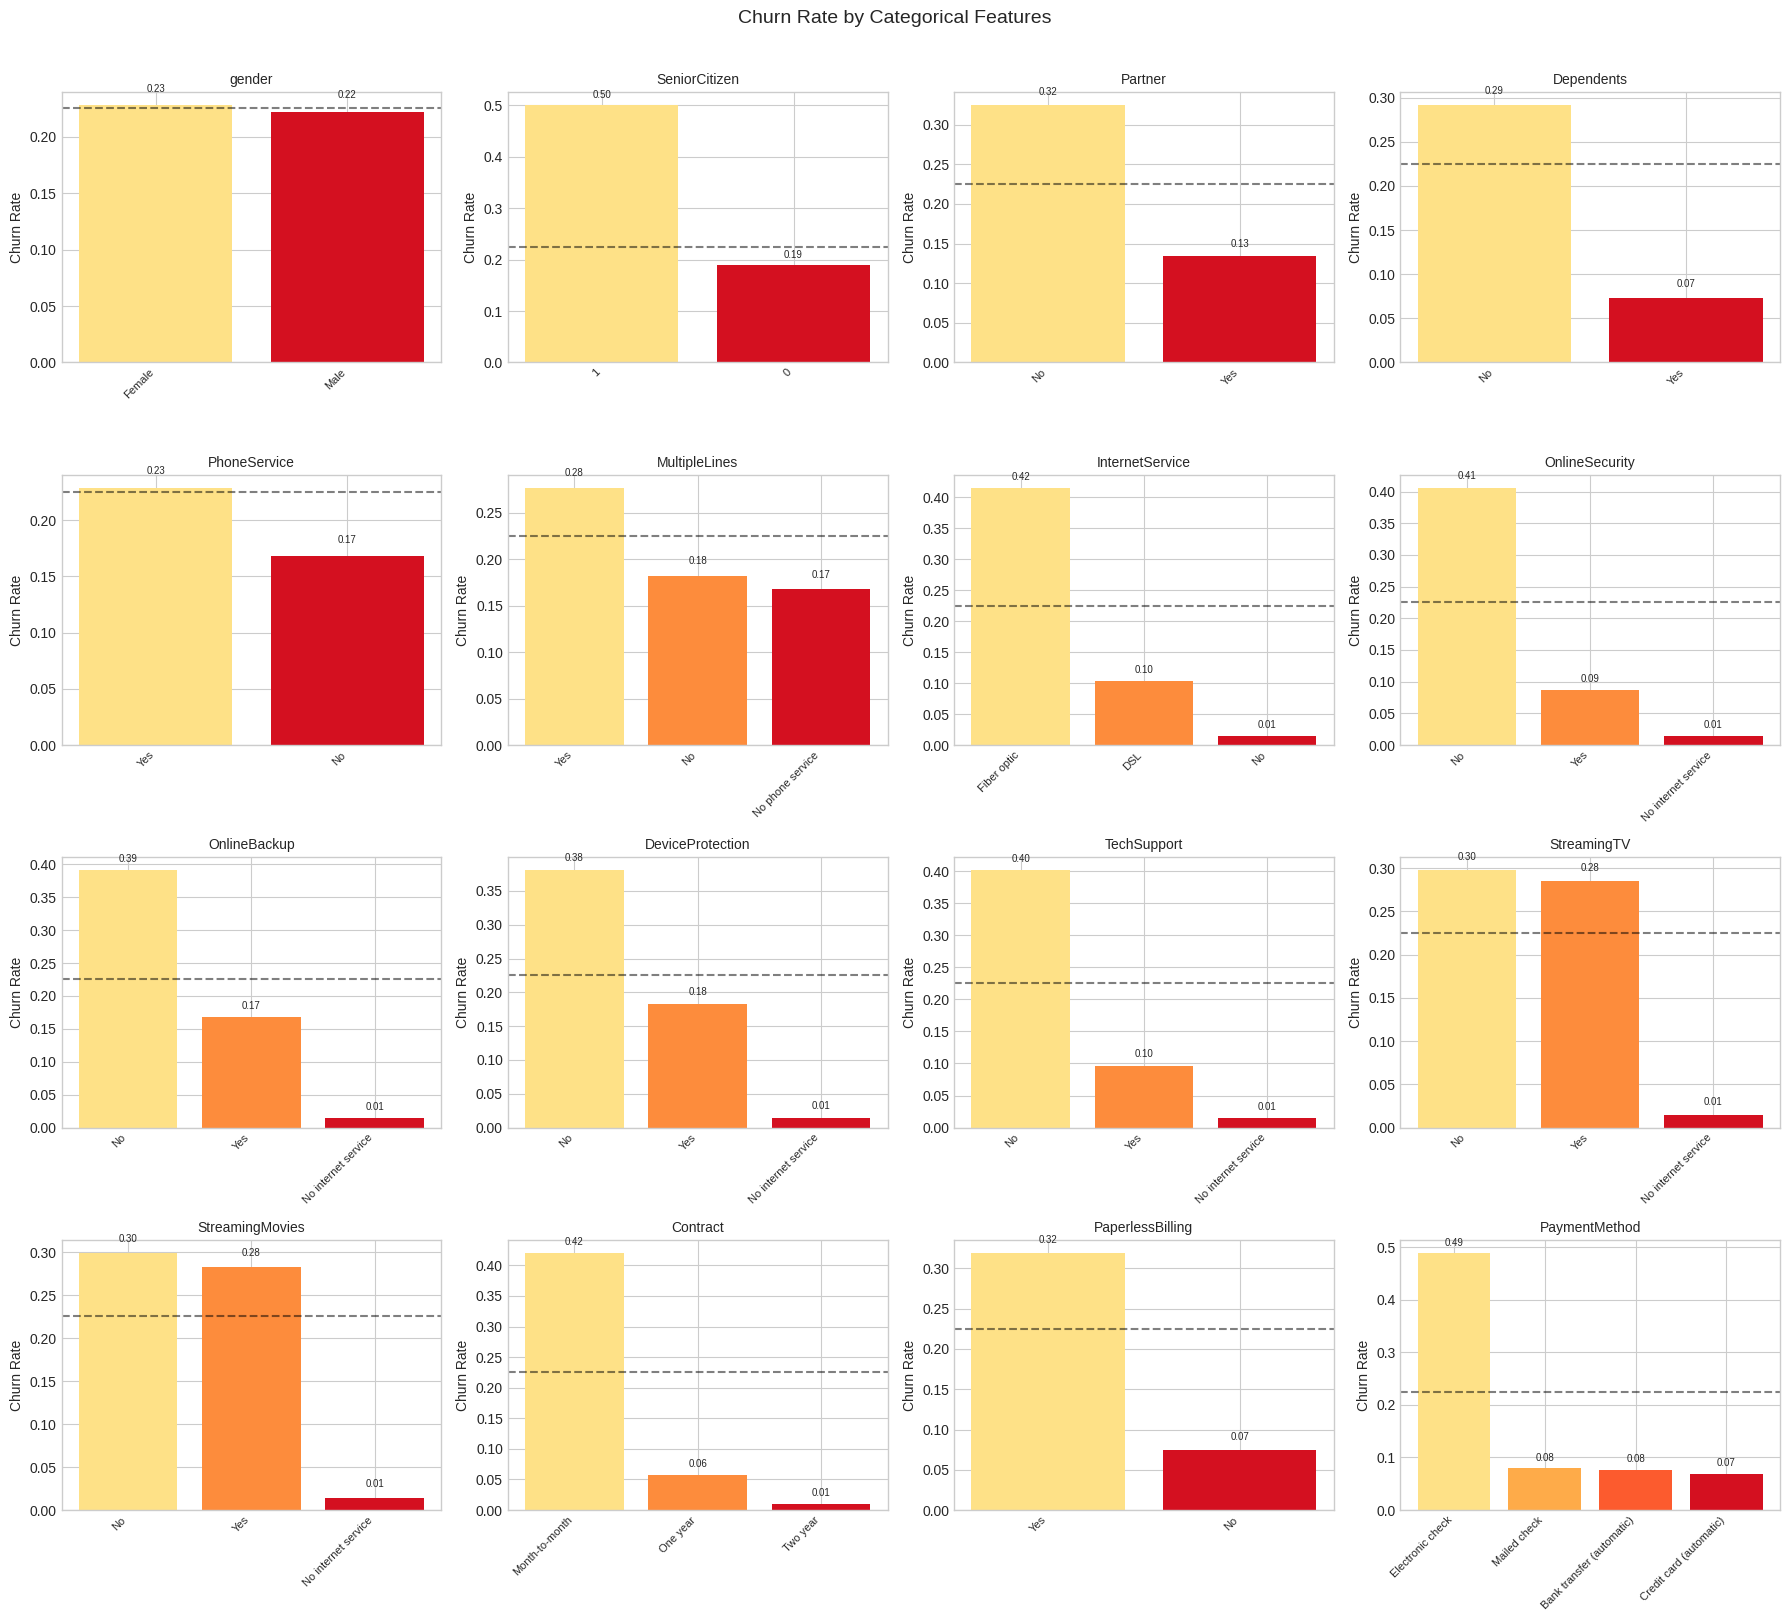

In [ ]:
# Phân tích các đặc điểm phân loại
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(CATS):
    # Tính tỷ lệ khách hàng rời bỏ theo từng danh mục
    churn_rate = train.groupby(col)[CFG.TARGET].mean().sort_values(ascending=False)
    
    colors = plt.cm.YlOrRd(np.linspace(0.2, 0.8, len(churn_rate)))
    bars = axes[idx].bar(range(len(churn_rate)), churn_rate.values, color=colors)
    axes[idx].set_xticks(range(len(churn_rate)))
    axes[idx].set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Churn Rate')
    axes[idx].set_title(f'{col}', fontsize=10)
    axes[idx].axhline(y=train[CFG.TARGET].mean(), color='black', linestyle='--', alpha=0.5)
    
    # Thêm nhãn giá trị
    for bar, val in zip(bars, churn_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                      f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

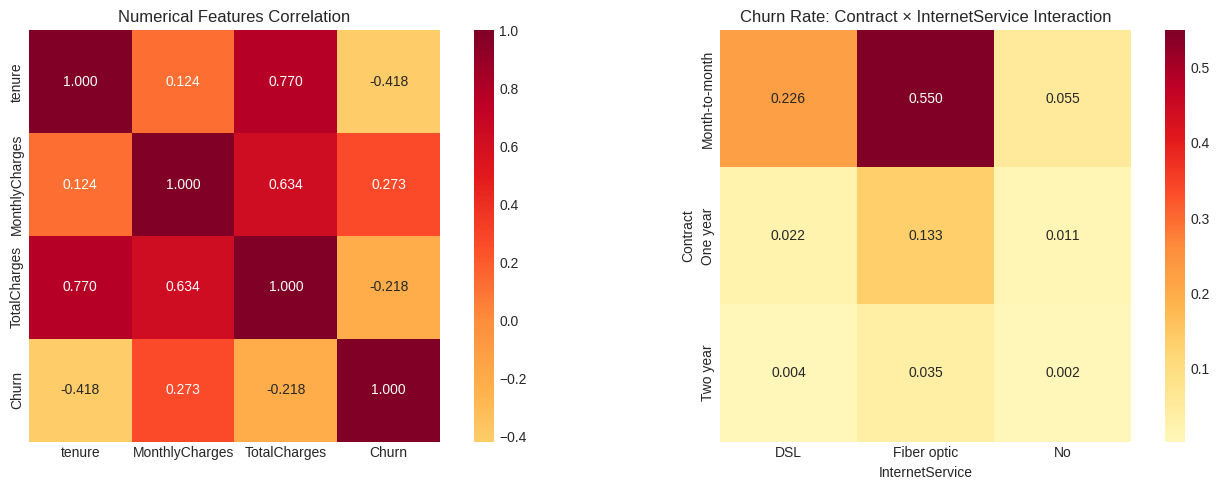


Note: Strong interaction between Contract type and InternetService!
This justifies using bi-gram/tri-gram composite features.


In [ ]:
# Ma trận tương quan cho các đặc trưng số
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tương quan số học
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = train[num_cols + [CFG.TARGET]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd', center=0, ax=axes[0], 
            fmt='.3f', square=True)
axes[0].set_title('Numerical Features Correlation')

# Tỷ lệ khách hàng rời bỏ dịch vụ hợp đồng so với dịch vụ Internet (mối tương quan quan trọng)
pivot = train.pivot_table(values=CFG.TARGET, index='Contract', 
                          columns='InternetService', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='YlOrRd', center=0.26, ax=axes[1], 
            fmt='.3f', square=True)
axes[1].set_title('Churn Rate: Contract × InternetService Interaction')

plt.tight_layout()
plt.show()

print("\nNote: Strong interaction between Contract type and InternetService!")
print("This justifies using bi-gram/tri-gram composite features.")

### 3.5 Những hiểu biết chính từ EDA

<div class="alert alert-success" style="border-radius: 8px; padding: 20px; background: #fff7ed; border: 1px solid #f97316;">

<h4 style="margin-top:0; color:#c2410c;">Những phát hiện chính</h4>

<ul>

<li><strong>Mất cân bằng lớp:</strong> Tập dữ liệu chứa khoảng 26% khách hàng đã rời bỏ, thể hiện sự mất cân bằng lớp ở mức độ vừa phải. Các chỉ số đánh giá như ROC-AUC được ưu tiên hơn độ chính xác.</li>

<li><strong>Loại hợp đồng:</strong> Thời hạn hợp đồng là yếu tố dự đoán mạnh nhất về tỷ lệ khách hàng rời bỏ. Khách hàng ký hợp đồng hàng tháng có tỷ lệ rời bỏ rất cao (~42%) so với khách hàng ký hợp đồng hai năm (~3%).</li>

<li><strong>Thời gian gắn bó của khách hàng:</strong> Tỷ lệ khách hàng rời bỏ tập trung ở những khách hàng mới. Xác suất khách hàng rời bỏ dịch vụ giảm đáng kể khi thời gian sử dụng dịch vụ tăng lên.

<li><strong>Dịch vụ Internet:</strong> Khách hàng sử dụng internet cáp quang có tỷ lệ rời bỏ dịch vụ cao hơn so với khách hàng sử dụng DSL hoặc khách hàng không có dịch vụ internet.</li>

<li><strong>Phương thức thanh toán:</strong> Người dùng séc điện tử có tỷ lệ rời bỏ dịch vụ cao hơn, có thể cho thấy hành vi thanh toán kém ổn định hơn.</li>

<li><strong>Sử dụng dịch vụ bổ sung:</strong> Khách hàng không sử dụng các dịch vụ bổ sung như <strong>Bảo mật trực tuyến</strong> hoặc <strong>Hỗ trợ kỹ thuật</strong> có khả năng rời bỏ dịch vụ cao hơn đáng kể.</li>

</ul>

</div>

## 4. Quy trình kỹ thuật đặc trưng

### 4.1 Tổng quan về kỹ thuật đặc trưng

Quy trình kỹ thuật đặc trưng bao gồm các thành phần sau:

| Bước | Loại đặc trưng | Mô tả |
|------|--------------|-------------|
| 1 | Mã hóa tần suất | Tần suất của các giá trị số trên tập huấn luyện/kiểm tra/gốc |
| 2 | Tương tác số học | Tỷ lệ và độ lệch được suy ra |
| 3 | Số lượng dịch vụ | Tổng hợp các đăng ký dịch vụ |
| 4 | ORIG_proba | Mã hóa mục tiêu từ tập dữ liệu gốc |
| 5 | Đặc trưng phân phối | Thứ hạng phần trăm, điểm z so với phân phối khách hàng rời bỏ/không rời bỏ |
| 6 | Khoảng cách lượng tử | Khoảng cách đến các lượng tử của phân phối khách hàng rời bỏ/không rời bỏ |
| 7 | Đặc trưng chữ số | Trích xuất các mẫu ở cấp độ chữ số từ các đặc trưng số |
| 8 | N-gram tổng hợp | Mã hóa mục tiêu phân loại Bi-gram và Tri-gram |

In [ ]:
# Xác định các nhóm tính năng
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
NUMS = ['tenure', 'MonthlyCharges', 'TotalCharges']

NEW_NUMS = []
NUM_AS_CAT = []

print("Feature Engineering Pipeline Started...")
print("="*60)

Feature Engineering Pipeline Started...


In [ ]:
# 1. Mã hóa tần số
print("[1/8] Creating Frequency Encoding features...")
for col in NUMS:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    for df in [train, test]:
        df[f'FREQ_{col}'] = df[col].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{col}')
print(f"    Created {len(NUMS)} frequency features")

[1/8] Creating Frequency Encoding features...
    Created 3 frequency features


In [ ]:
# 2. Tương tác số học
print("[2/8] Creating Arithmetic Interaction features...")
for df in [train, test]:
    df['charges_deviation'] = (df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
    df['avg_monthly_charges'] = (df['TotalCharges'] / (df['tenure'] + 1)).astype('float32')
NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']
print(f"    Created 3 arithmetic features")

[2/8] Creating Arithmetic Interaction features...
    Created 3 arithmetic features


In [ ]:
# 3. Dịch vụ rất quan trọng
print("[3/8] Creating Service Count features...")
SERVICE_COLS = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for df in [train, test]:
    df['service_count'] = (df[SERVICE_COLS] == 'Yes').sum(axis=1).astype('float32')
    df['has_internet'] = (df['InternetService'] != 'No').astype('float32')
    df['has_phone'] = (df['PhoneService'] == 'Yes').astype('float32')
NEW_NUMS += ['service_count', 'has_internet', 'has_phone']
print(f"    Created 3 service count features")

[3/8] Creating Service Count features...
    Created 3 service count features


In [ ]:
# 4. Ánh xạ ORIG_proba
print("[4/8] Creating ORIG_proba features...")
for col in CATS + NUMS:
    tmp = orig.groupby(col)[CFG.TARGET].mean()
    _name = f"ORIG_proba_{col}"
    train = train.merge(tmp.rename(_name), on=col, how="left")
    test = test.merge(tmp.rename(_name), on=col, how="left")
    for df in [train, test]:
        df[_name] = df[_name].fillna(0.5).astype('float32')
    NEW_NUMS.append(_name)
print(f"    Created {len(CATS + NUMS)} ORIG_proba features")

[4/8] Creating ORIG_proba features...
    Created 19 ORIG_proba features


In [ ]:
# 5. Đặc điểm phân phối
print("[5/8] Creating Distribution Features (percentile ranks, z-scores)...")

def pctrank_against(values, reference):
    ref_sorted = np.sort(reference)
    return (np.searchsorted(ref_sorted, values) / len(ref_sorted)).astype('float32')

def zscore_against(values, reference):
    mu, sigma = np.mean(reference), np.std(reference)
    return (np.zeros(len(values), dtype='float32') if sigma == 0 
            else ((values - mu) / sigma).astype('float32'))

orig_churner_tc = orig.loc[orig[CFG.TARGET] == 1, 'TotalCharges'].values
orig_nonchurner_tc = orig.loc[orig[CFG.TARGET] == 0, 'TotalCharges'].values
orig_tc = orig['TotalCharges'].values
orig_is_mc_mean = orig.groupby('InternetService')['MonthlyCharges'].mean()

for df in [train, test]:
    tc = df['TotalCharges'].values
    df['pctrank_nonchurner_TC'] = pctrank_against(tc, orig_nonchurner_tc)
    df['pctrank_churner_TC'] = pctrank_against(tc, orig_churner_tc)
    df['pctrank_orig_TC'] = pctrank_against(tc, orig_tc)
    df['zscore_churn_gap_TC'] = (np.abs(zscore_against(tc, orig_churner_tc)) - 
                                 np.abs(zscore_against(tc, orig_nonchurner_tc))).astype('float32')
    df['zscore_nonchurner_TC'] = zscore_against(tc, orig_nonchurner_tc)
    df['pctrank_churn_gap_TC'] = (pctrank_against(tc, orig_churner_tc) - 
                                  pctrank_against(tc, orig_nonchurner_tc)).astype('float32')
    df['resid_IS_MC'] = (df['MonthlyCharges'] - df['InternetService'].map(orig_is_mc_mean).fillna(0)).astype('float32')
    
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in orig['InternetService'].unique():
        mask = df['InternetService'] == cat_val
        ref = orig.loc[orig['InternetService'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_IS_TC'] = vals
    
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in orig['Contract'].unique():
        mask = df['Contract'] == cat_val
        ref = orig.loc[orig['Contract'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_C_TC'] = vals

DIST_FEATURES = [
    'pctrank_nonchurner_TC', 'zscore_churn_gap_TC', 'pctrank_churn_gap_TC',
    'resid_IS_MC', 'cond_pctrank_IS_TC', 'zscore_nonchurner_TC',
    'pctrank_orig_TC', 'pctrank_churner_TC', 'cond_pctrank_C_TC'
]
NEW_NUMS += DIST_FEATURES
print(f"    Created {len(DIST_FEATURES)} distribution features")

[5/8] Creating Distribution Features (percentile ranks, z-scores)...
    Created 9 distribution features


In [ ]:
# 6. Đặc điểm khoảng cách phân vị
print("[6/8] Creating Quantile Distance Features...")
for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q = np.quantile(orig_churner_tc, q_val)
    nc_q = np.quantile(orig_nonchurner_tc, q_val)
    for df in [train, test]:
        df[f'dist_To_ch_{q_label}'] = np.abs(df['TotalCharges'] - ch_q).astype('float32')
        df[f'dist_To_nc_{q_label}'] = np.abs(df['TotalCharges'] - nc_q).astype('float32')
        df[f'qdist_gap_To_{q_label}'] = (df[f'dist_To_nc_{q_label}'] - df[f'dist_To_ch_{q_label}']).astype('float32')

QDIST_FEATURES = [
    'qdist_gap_To_q50', 'dist_To_ch_q50', 'dist_To_nc_q50',
    'dist_To_nc_q25', 'qdist_gap_To_q25',
    'dist_To_nc_q75', 'dist_To_ch_q75', 'qdist_gap_To_q75'
]
NEW_NUMS += QDIST_FEATURES
print(f"    Created {len(QDIST_FEATURES)} quantile distance features")

[6/8] Creating Quantile Distance Features...
    Created 8 quantile distance features


In [ ]:
# 7. Đặc điểm của chữ số từ các số
print("[7/8] Creating Digit Features from Numericals...")

DIGIT_FEATURES = [
    'tenure_first_digit', 'tenure_last_digit', 'tenure_second_digit',
    'tenure_mod10', 'tenure_mod12', 'tenure_num_digits',
    'tenure_is_multiple_10', 'tenure_rounded_10', 'tenure_dev_from_round10',
    'mc_first_digit', 'mc_last_digit', 'mc_second_digit',
    'mc_mod10', 'mc_mod100', 'mc_num_digits', 
    'mc_is_multiple_10', 'mc_is_multiple_50',
    'mc_rounded_10', 'mc_fractional', 'mc_dev_from_round10',
    'tc_first_digit', 'tc_last_digit', 'tc_second_digit',
    'tc_mod10', 'tc_mod100', 'tc_num_digits',
    'tc_is_multiple_10', 'tc_is_multiple_100',
    'tc_rounded_100', 'tc_fractional', 'tc_dev_from_round100',
    'tenure_years', 'tenure_months_in_year', 'mc_per_digit', 'tc_per_digit'
]

for df in [train, test]:
    # Tenure digits
    t_str = df['tenure'].astype(str)
    df['tenure_first_digit'] = t_str.str[0].astype(int)
    df['tenure_last_digit'] = t_str.str[-1].astype(int)
    df['tenure_second_digit'] = t_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    df['tenure_mod10'] = df['tenure'] % 10
    df['tenure_mod12'] = df['tenure'] % 12
    df['tenure_num_digits'] = t_str.str.len()
    df['tenure_is_multiple_10'] = (df['tenure'] % 10 == 0).astype('float32')
    df['tenure_rounded_10'] = np.round(df['tenure'] / 10) * 10
    df['tenure_dev_from_round10'] = np.abs(df['tenure'] - df['tenure_rounded_10'])

    # MonthlyCharges
    mc_str = df['MonthlyCharges'].astype(str).str.replace('.', '', regex=False)
    df['mc_first_digit'] = mc_str.str[0].astype(int)
    df['mc_last_digit'] = mc_str.str[-1].astype(int)
    df['mc_second_digit'] = mc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    df['mc_mod10'] = np.floor(df['MonthlyCharges']) % 10
    df['mc_mod100'] = np.floor(df['MonthlyCharges']) % 100
    df['mc_num_digits'] = np.floor(df['MonthlyCharges']).astype(int).astype(str).str.len()
    df['mc_is_multiple_10'] = (np.floor(df['MonthlyCharges']) % 10 == 0).astype('float32')
    df['mc_is_multiple_50'] = (np.floor(df['MonthlyCharges']) % 50 == 0).astype('float32')
    df['mc_rounded_10'] = np.round(df['MonthlyCharges'] / 10) * 10
    df['mc_fractional'] = df['MonthlyCharges'] - np.floor(df['MonthlyCharges'])
    df['mc_dev_from_round10'] = np.abs(df['MonthlyCharges'] - df['mc_rounded_10'])

    # TotalCharges
    tc_str = df['TotalCharges'].astype(str).str.replace('.', '', regex=False)
    df['tc_first_digit'] = tc_str.str[0].astype(int)
    df['tc_last_digit'] = tc_str.str[-1].astype(int)
    df['tc_second_digit'] = tc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    df['tc_mod10'] = np.floor(df['TotalCharges']) % 10
    df['tc_mod100'] = np.floor(df['TotalCharges']) % 100
    df['tc_num_digits'] = np.floor(df['TotalCharges']).astype(int).astype(str).str.len()
    df['tc_is_multiple_10'] = (np.floor(df['TotalCharges']) % 10 == 0).astype('float32')
    df['tc_is_multiple_100'] = (np.floor(df['TotalCharges']) % 100 == 0).astype('float32')
    df['tc_rounded_100'] = np.round(df['TotalCharges'] / 100) * 100
    df['tc_fractional'] = df['TotalCharges'] - np.floor(df['TotalCharges'])
    df['tc_dev_from_round100'] = np.abs(df['TotalCharges'] - df['tc_rounded_100'])

    # Derived
    df['tenure_years'] = df['tenure'] // 12
    df['tenure_months_in_year'] = df['tenure'] % 12
    df['mc_per_digit'] = df['MonthlyCharges'] / (df['mc_num_digits'] + 0.001)
    df['tc_per_digit'] = df['TotalCharges'] / (df['tc_num_digits'] + 0.001)

    # Bắt buộc sử dụng float32
    for c in DIGIT_FEATURES:
        df[c] = df[c].astype('float32')

NEW_NUMS += DIGIT_FEATURES
print(f"    Created {len(DIGIT_FEATURES)} digit features")

[7/8] Creating Digit Features from Numericals...
    Created 35 digit features


In [ ]:
# 8. Numerical-as-Category
print("[8/8] Creating Numerical-as-Category features...")

for col in NUMS:
    _new = f'CAT_{col}'
    NUM_AS_CAT.append(_new)
    for df in [train, test]:
        df[_new] = df[col].astype(str).astype('category')

print(f"    Created {len(NUM_AS_CAT)} numerical-as-category features")

[8/8] Creating Numerical-as-Category features...
    Created 3 numerical-as-category features


In [ ]:
# Phân loại tổng hợp N-gram
print("\n" + "="*60)
print("Creating N-gram Composite Categorical Features...")
print("="*60)

BIGRAM_COLS = []
TRIGRAM_COLS = []

# Bi-gram: tất cả các cặp từ 6 CAT hàng đầu = C(6,2) = 15 cặp
print(f"\nCreating Bi-gram features from top {len(TOP_CATS_FOR_NGRAM)} categoricals:")
print(f"  Columns: {TOP_CATS_FOR_NGRAM}")
for c1, c2 in combinations(TOP_CATS_FOR_NGRAM, 2):
    col_name = f"BG_{c1}_{c2}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str)).astype('category')
    BIGRAM_COLS.append(col_name)

print(f"  Created {len(BIGRAM_COLS)} bi-gram features")

# Tri-gram: chỉ lấy top 4 CAT hàng đầu = C(4,3) = 4 cặp
TOP4 = TOP_CATS_FOR_NGRAM[:4]
print(f"\nCreating Tri-gram features from top 4 categoricals:")
print(f"  Columns: {TOP4}")
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f"TG_{c1}_{c2}_{c3}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str) + "_" + df[c3].astype(str)).astype('category')
    TRIGRAM_COLS.append(col_name)

print(f"  Created {len(TRIGRAM_COLS)} tri-gram features")

NGRAM_COLS = BIGRAM_COLS + TRIGRAM_COLS
print(f"\nTotal N-gram features: {len(NGRAM_COLS)}")


Creating N-gram Composite Categorical Features...

Creating Bi-gram features from top 6 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
  Created 15 bi-gram features

Creating Tri-gram features from top 4 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']
  Created 4 tri-gram features

Total N-gram features: 19


In [ ]:
# Tóm tắt tính năng

# Xác định các nhóm tính năng cho TE
FEATURES = NUMS + CATS + NEW_NUMS + NUM_AS_CAT + NGRAM_COLS
TE_COLUMNS = NUM_AS_CAT + CATS     # Columns for target encoding
TE_NGRAM_COLUMNS = NGRAM_COLS      # N-gram columns for target encoding
TO_REMOVE = NUM_AS_CAT + CATS + NGRAM_COLS
STATS = ['std', 'min', 'max']

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"Total Features: {len(FEATURES)}")
print(f"  - Numerical:            {len(NUMS)}")
print(f"  - Categorical:          {len(CATS)}")
print(f"  - Engineered Numerical: {len(NEW_NUMS)}")
print(f"  - Num-as-Cat:           {len(NUM_AS_CAT)}")
print(f"  - N-gram (Bi+Tri):      {len(NGRAM_COLS)}")


FEATURE ENGINEERING COMPLETE
Total Features: 121
  - Numerical:            3
  - Categorical:          16
  - Engineered Numerical: 80
  - Num-as-Cat:           3
  - N-gram (Bi+Tri):      19



## 5. Huấn luyện mô hình

### 5.1 Huấn luyện CatBoost với kiểm định chéo 20 lần

<div style="background: linear-gradient(135deg, #fff7ed 0%, #ffedd5 100%); padding: 20px; border-radius: 10px; border-left: 4px solid #f97316; margin: 15px 0;">

<h4 style="margin-top:0; color: #c2410c;">🔥 Chiến lược huấn luyện CatBoost</h4>

<ul style="color: #7c2d12;">

<li><strong>Vòng lặp ngoài:</strong> Kiểm định chéo phân tầng 20 lần để ước tính hiệu suất mạnh mẽ</li>
<li><strong>Vòng lặp trong:</strong> Mã hóa mục tiêu 5 lần để ngăn chặn rò rỉ dữ liệu</li>
<li><strong>Tăng tốc GPU:</strong> Sử dụng CUDA giúp tăng tốc độ các vòng lặp huấn luyện</li>
<li><strong>Dừng sớm:</strong> Kiên nhẫn 200 vòng để ngăn ngừa hiện tượng quá khớp</li>
<li><strong>Cây đối xứng:</strong> Chính sách phát triển được tối ưu hóa bởi Optuna cho các phân chia cân bằng</li>
</ul>

</div>

In [ ]:
# Huấn luyện mô hình với phương pháp kiểm chứng chéo 20 lần
print("\n" + "="*60)
print(f"TRAINING CATBOOST WITH {CFG.N_FOLDS}-FOLD CROSS-VALIDATION")
print("="*60)

np.random.seed(CFG.RANDOM_SEED)
skf_outer = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)
skf_inner = StratifiedKFold(n_splits=CFG.INNER_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)

cat_oof = np.zeros(len(train))
cat_pred = np.zeros(len(test))
cat_fold_scores = []

t0 = time.time()

for i, (train_idx, val_idx) in enumerate(skf_outer.split(train, train[CFG.TARGET])):
    print(f"\n{'='*50}")
    print(f"Fold {i+1}/{CFG.N_FOLDS}")
    print(f"{'='*50}")
    
    X_tr  = train.loc[train_idx, FEATURES + [CFG.TARGET]].reset_index(drop=True).copy()
    y_tr  = train.loc[train_idx, CFG.TARGET].values
    X_val = train.loc[val_idx, FEATURES].reset_index(drop=True).copy()
    y_val = train.loc[val_idx, CFG.TARGET].values
    X_te  = test[FEATURES].reset_index(drop=True).copy()
    
    # KFold TE bên trong cho các biến phân loại + NUM_AS_CAT
    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2 = X_tr.loc[in_tr, FEATURES + [CFG.TARGET]].copy()
        X_va2 = X_tr.loc[in_va, FEATURES].copy()
        for col in TE_COLUMNS:
            tmp = X_tr2.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
            tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
            X_va2 = X_va2.merge(tmp, on=col, how="left")
            for c in tmp.columns:
                X_tr.loc[in_va, c] = X_va2[c].values.astype("float32")
                
    for col in TE_COLUMNS:
        tmp = X_tr.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
        tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
        tmp = tmp.astype("float32")
        X_val = X_val.merge(tmp, on=col, how="left")
        X_te = X_te.merge(tmp, on=col, how="left")
        for c in tmp.columns:
            for df in [X_tr, X_val, X_te]:
                df[c] = df[c].fillna(0)
    
    # Phương pháp TE KFold bên trong cho N-gram
    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2 = X_tr.loc[in_tr].copy()
        X_va2 = X_tr.loc[in_va].copy()
        for col in TE_NGRAM_COLUMNS:
            ng_te = X_tr2.groupby(col, observed=False)[CFG.TARGET].mean()
            ng_name = f"TE_ng_{col}"
            mapped = X_va2[col].astype(str).map(ng_te)
            X_tr.loc[in_va, ng_name] = pd.to_numeric(mapped, errors='coerce').fillna(0.5).astype('float32').values
    
    for col in TE_NGRAM_COLUMNS:
        ng_te = X_tr.groupby(col, observed=False)[CFG.TARGET].mean()
        ng_name = f"TE_ng_{col}"
        X_val[ng_name] = pd.to_numeric(X_val[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        X_te[ng_name] = pd.to_numeric(X_te[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        if ng_name in X_tr.columns:
            X_tr[ng_name] = pd.to_numeric(X_tr[ng_name], errors='coerce').fillna(0.5).astype('float32')
        else:
            X_tr[ng_name] = 0.5
                
    # sklearn TargetEncoder
    TE_MEAN_COLS = [f'TE_{col}' for col in TE_COLUMNS]
    te = TargetEncoder(cv=CFG.INNER_FOLDS, shuffle=True, smooth='auto', target_type='binary', random_state=CFG.RANDOM_SEED)
    X_tr[TE_MEAN_COLS] = te.fit_transform(X_tr[TE_COLUMNS], y_tr)
    X_val[TE_MEAN_COLS] = te.transform(X_val[TE_COLUMNS])
    X_te[TE_MEAN_COLS] = te.transform(X_te[TE_COLUMNS])
    
    # Chuẩn bị cho CatBoost — loại bỏ các dữ liệu phân loại thô
    for df in [X_tr, X_val, X_te]:
        df.drop(columns=[c for c in TO_REMOVE if c in df.columns], inplace=True, errors='ignore')
    X_tr.drop(columns=[CFG.TARGET], inplace=True, errors='ignore')
    COLS_CAT = X_tr.columns
    
    if i == 0:
        n_feats = len(COLS_CAT)
        print(f"\n  Features for CatBoost: {n_feats}")
    
    # Train model
    train_pool = Pool(data=X_tr, label=y_tr)
    val_pool = Pool(data=X_val, label=y_val)
    
    model = CatBoostClassifier(**CAT_PARAMS)
    model.fit(train_pool, eval_set=val_pool, verbose=0)
    
    # Lưu kết quả
    cat_oof[val_idx] = model.predict_proba(val_pool)[:, 1]
    fold_auc = roc_auc_score(y_val, cat_oof[val_idx])
    cat_fold_scores.append(fold_auc)
    
    fold_test_p = model.predict_proba(X_te[COLS_CAT])[:, 1]
    cat_pred += fold_test_p / CFG.N_FOLDS
    
    print(f"   Fold {i+1} AUC: {fold_auc:.5f} | Time: {(time.time()-t0)/60:.1f} min")
    
    del X_tr, X_val, X_te, y_tr, y_val, model, train_pool, val_pool
    gc.collect()

print(f"\n{'='*60}")
print("TRAINING COMPLETE!")
print(f"{'='*60}")


TRAINING CATBOOST WITH 20-FOLD CROSS-VALIDATION

Fold 1/20

  Features for CatBoost: 178


Default metric period is 5 because AUC is/are not implemented for GPU


   Fold 1 AUC: 0.92026 | Time: 2.8 min

Fold 2/20


Default metric period is 5 because AUC is/are not implemented for GPU


   Fold 2 AUC: 0.91837 | Time: 5.1 min

Fold 3/20


...

   Fold 18 AUC: 0.91782 | Time: 41.8 min

Fold 19/20


Default metric period is 5 because AUC is/are not implemented for GPU


   Fold 19 AUC: 0.91822 | Time: 44.3 min

Fold 20/20


Default metric period is 5 because AUC is/are not implemented for GPU


   Fold 20 AUC: 0.91535 | Time: 46.5 min

TRAINING COMPLETE!


In [ ]:
# Tính toán các chỉ số tổng thể
overall_auc = roc_auc_score(train[CFG.TARGET], cat_oof)
mean_score = np.mean(cat_fold_scores)
std_score = np.std(cat_fold_scores)

print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nOverall CV AUC:  {overall_auc:.5f}")
print(f"Mean Fold AUC:   {mean_score:.5f} +/- {std_score:.5f}")
print(f"\nPer-Fold Scores:")
for i, score in enumerate(cat_fold_scores):
    status = '✅' if score >= mean_score else '⚠️'
    print(f"  Fold {i+1:2d}: {score:.5f} {status}")

MODEL PERFORMANCE SUMMARY

Overall CV AUC:  0.91902
Mean Fold AUC:   0.91902 +/- 0.00178

Per-Fold Scores:
  Fold  1: 0.92026 ✅
  Fold  2: 0.91837 ⚠️
  Fold  3: 0.91788 ⚠️
  Fold  4: 0.91868 ⚠️
  Fold  5: 0.92303 ✅
  Fold  6: 0.91855 ⚠️
  Fold  7: 0.91650 ⚠️
  Fold  8: 0.92042 ✅
  Fold  9: 0.91873 ⚠️
  Fold 10: 0.91848 ⚠️
  Fold 11: 0.91873 ⚠️
  Fold 12: 0.91979 ✅
  Fold 13: 0.92154 ✅
  Fold 14: 0.92046 ✅
  Fold 15: 0.91729 ⚠️
  Fold 16: 0.92168 ✅
  Fold 17: 0.91866 ⚠️
  Fold 18: 0.91782 ⚠️
  Fold 19: 0.91822 ⚠️
  Fold 20: 0.91535 ⚠️


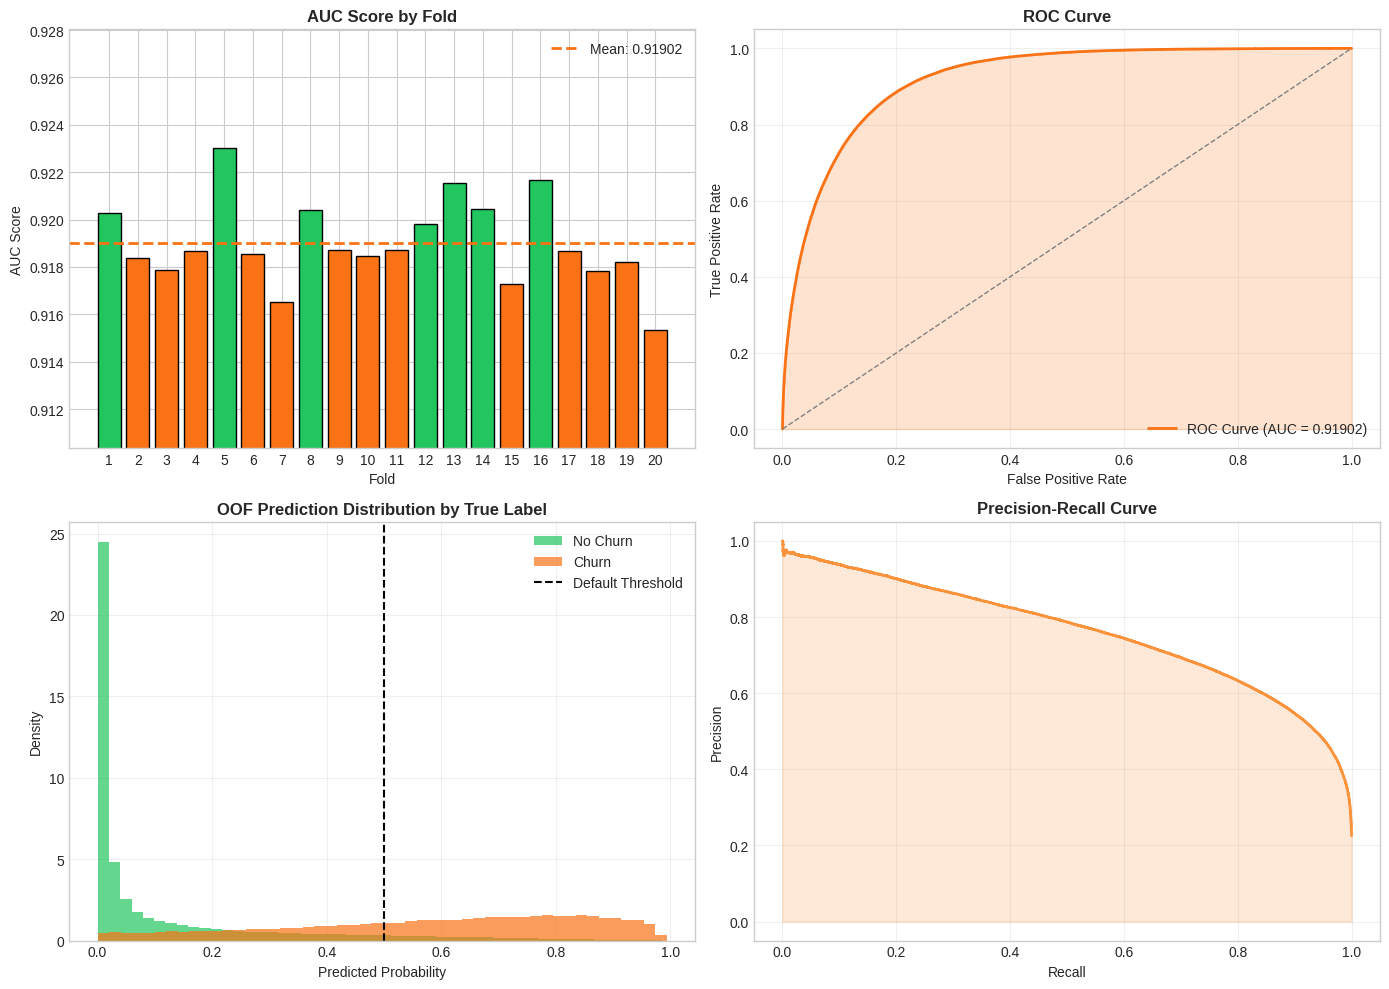

In [ ]:
# Trực quan hóa: Fold Performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fold AUC Scores
ax1 = axes[0, 0]
colors = ['#22c55e' if s >= mean_score else '#f97316' for s in cat_fold_scores]
bars = ax1.bar(range(1, CFG.N_FOLDS + 1), cat_fold_scores, color=colors, edgecolor='black')
ax1.axhline(y=mean_score, color='#f97316', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.5f}')
ax1.set_xlabel('Fold')
ax1.set_ylabel('AUC Score')
ax1.set_title('AUC Score by Fold', fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, CFG.N_FOLDS + 1))
ax1.legend()
ax1.set_ylim([min(cat_fold_scores) - 0.005, max(cat_fold_scores) + 0.005])

# 2. ROC Curve
ax2 = axes[0, 1]
fpr, tpr, thresholds = roc_curve(train[CFG.TARGET], cat_oof)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='#f97316', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.5f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
ax2.fill_between(fpr, tpr, alpha=0.2, color='#f97316')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. Prediction Distribution
ax3 = axes[1, 0]
ax3.hist(cat_oof[train[CFG.TARGET] == 0], bins=50, alpha=0.7, label='No Churn', color='#22c55e', density=True)
ax3.hist(cat_oof[train[CFG.TARGET] == 1], bins=50, alpha=0.7, label='Churn', color='#f97316', density=True)
ax3.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold')
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Density')
ax3.set_title('OOF Prediction Distribution by True Label', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Precision-Recall Curve
ax4 = axes[1, 1]
precision, recall, _ = precision_recall_curve(train[CFG.TARGET], cat_oof)
ax4.plot(recall, precision, color='#fb923c', linewidth=2)
ax4.fill_between(recall, precision, alpha=0.2, color='#fb923c')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

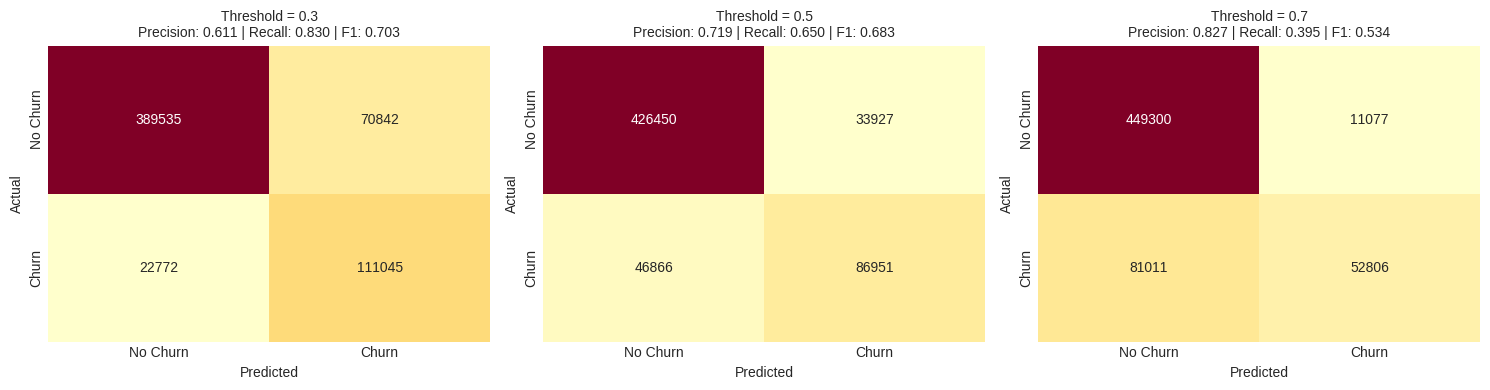


Note: Lower threshold = higher recall (catch more churners)
      Higher threshold = higher precision (more confident predictions)


In [ ]:
# Ma trận nhầm lẫn ở các ngưỡng khác nhau
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
thresholds = [0.3, 0.5, 0.7]

for ax, thresh in zip(axes, thresholds):
    y_pred = (cat_oof >= thresh).astype(int)
    cm = confusion_matrix(train[CFG.TARGET], y_pred)
    
    # Tính toán các chỉ số
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Threshold = {thresh}\nPrecision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}', 
                fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: Lower threshold = higher recall (catch more churners)")
print("      Higher threshold = higher precision (more confident predictions)")

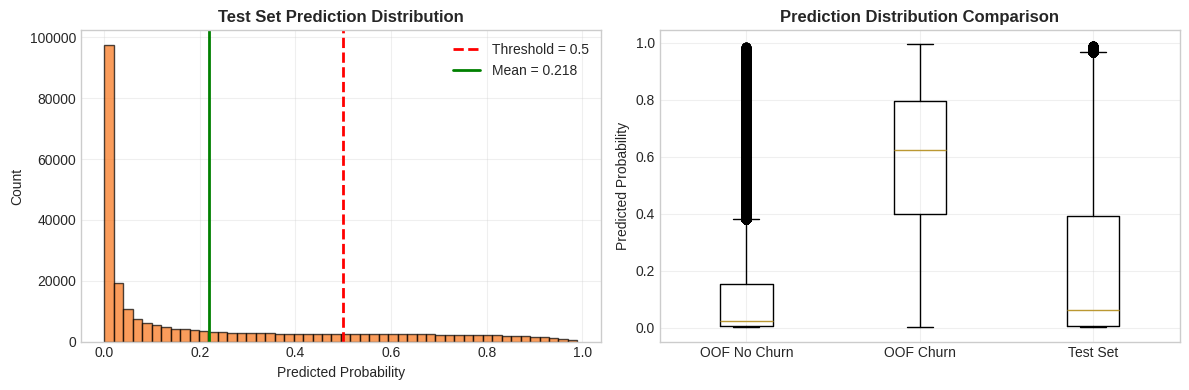


Test Set Statistics:
  Mean prediction: 0.2184
  Std prediction:  0.2780
  Min prediction:  0.0004
  Max prediction:  0.9898
  Predicted churn rate (threshold=0.5): 19.51%


In [ ]:
# Phân phối dự đoán của tập dữ liệu kiểm thử
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ tần số
axes[0].hist(cat_pred, bins=50, color='#f97316', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[0].axvline(x=np.mean(cat_pred), color='green', linestyle='-', linewidth=2, label=f'Mean = {np.mean(cat_pred):.3f}')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Test Set Prediction Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# So sánh biểu đồ hộp
axes[1].boxplot([cat_oof[train[CFG.TARGET] == 0], cat_oof[train[CFG.TARGET] == 1], cat_pred],
               labels=['OOF No Churn', 'OOF Churn', 'Test Set'])
axes[1].set_ylabel('Predicted Probability')
axes[1].set_title('Prediction Distribution Comparison', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTest Set Statistics:")
print(f"  Mean prediction: {np.mean(cat_pred):.4f}")
print(f"  Std prediction:  {np.std(cat_pred):.4f}")
print(f"  Min prediction:  {np.min(cat_pred):.4f}")
print(f"  Max prediction:  {np.max(cat_pred):.4f}")
print(f"  Predicted churn rate (threshold=0.5): {(cat_pred >= 0.5).mean()*100:.2f}%")

In [ ]:
# Lưu các dự đoán OOF
oof_df = pd.DataFrame({
    'id': train_ids,
    CFG.TARGET: cat_oof
})
oof_df.to_csv('oof_predictions.csv', index=False)
print(f"OOF predictions saved to 'oof_predictions.csv'")
print(f"  Shape: {oof_df.shape}")
display(oof_df.head())

# Lưu các dự đoán kiểm thử (tệp nộp)
sub_df = pd.DataFrame({
    'id': test_ids,
    CFG.TARGET: cat_pred
})
sub_df.to_csv('submission.csv', index=False)
print(f"\nSubmission saved to 'submission.csv'")
print(f"  Shape: {sub_df.shape}")
display(sub_df.head())

OOF predictions saved to 'oof_predictions.csv'
  Shape: (594194, 2)


,id,Churn
0,0,0.009431
1,1,0.002149
2,2,0.307057
3,3,0.672454
4,4,0.797958



Submission saved to 'submission.csv'
  Shape: (254655, 2)


,id,Churn
0,594194,0.130155
1,594195,0.001045
2,594196,0.122425
3,594197,0.002996
4,594198,0.532151


### Các yếu tố thành công chính

<div class="alert alert-success" style="border-radius: 8px; padding: 20px; margin: 15px 0; background: #fff7ed; border: 1px solid #f97316;">

<h4 style="margin-top: 0; color: #c2410c;">Điều gì đã làm nên hiệu quả của giải pháp này</h4>

<ul style="color: #7c2d12; margin-bottom: 0;">

<li><strong>Tham số siêu tối ưu hóa Optuna:</strong> Các tham số CatBoost được tinh chỉnh thông qua tối ưu hóa Bayes</li>

<li><strong>Tăng trưởng cây đối xứng:</strong> Cấu trúc cây cân bằng cho suy luận nhanh hơn và dự đoán mạnh mẽ</li>

<li><strong>Kỹ thuật đặc trưng toàn diện:</strong> Quy trình 8 bước tạo ra các tín hiệu dự đoán đa dạng</li>

<li><strong>Đặc trưng tổng hợp N-gram:</strong> Thu thập thông tin 2 chiều và tương tác phân loại 3 chiều</li>

<li><strong>Kiểm định mạnh mẽ:</strong> Kiểm định chéo phân tầng 20 lần với kiểm định chéo 5 lần bên trong giúp ngăn ngừa hiện tượng quá khớp</li>

</ul>

</div>

### Cải tiến trong tương lai

<div class="alert alert-warning" style="border-radius: 8px; padding: 20px; margin: 15px 0; background: #fef3c7; border: 1px solid #f59e0b;">

<h4 style="margin-top: 0; color: #92400e;">Những cải tiến tiềm năng</h4>

<ul style="color: #78350f; margin-bottom: 0;">

<li>Kết hợp với XGBoost và LightGBM để đa dạng hóa mô hình</li>

<li>Các mô hình bảng thần kinh (TabNet, FT-Transformer)</li>

<li>Lựa chọn đặc trưng thông qua phân tích SHAP</li> <li>Ghép nhiều dự đoán mô hình</li>

<li>Tìm kiếm siêu tham số mở rộng với nhiều thử nghiệm Optuna hơn</li>

</ul>
</div>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 30px; border-radius: 12px; margin-top: 20px;">

<h3 style="color: #ffffff; margin-top: 0;">🐱 Tóm tắt giải pháp CatBoost</h3>

<p style="color: #94a3b8; font-size: 14px;">

<strong style="color: #f97316;">Kiến trúc mô hình:</strong> Bộ phân loại CatBoost với sự phát triển cây đối xứng được tối ưu hóa bởi Optuna

</p>

<p style="color: #94a3b8; font-size: 14px;">

<strong style="color: #fb923c;">Đổi mới chính:</strong> Các siêu tham số được tối ưu hóa bởi Optuna kết hợp với mã hóa phân loại tổng hợp N-gram

</p>

<p style="color: #94a3b8; font-size: 14px;">
<strong style="color: #fdba74;">Kỹ thuật đặc trưng:</strong> Quy trình 8 bước bao gồm mã hóa tần số, đặc trưng phân phối, khoảng cách lượng tử, đặc trưng chữ số và mã hóa N-gram
</p>

<p style="color: #94a3b8; font-size: 14px;">
<strong style="color: #f97316;">Kiểm chứng:</strong> Kiểm chứng chéo phân tầng 20 lần với mã hóa mục tiêu 5 lần bên trong
</p>

<hr style="border: none; height: 1px; background: #374151; margin: 20px 0;">

<p style="color: #e2e8f0; font-size: 14px;">
Sổ tay này minh họa hiệu quả của kiến ​​trúc cây đối xứng của CatBoost kết hợp với các siêu tham số được tối ưu hóa bằng Optuna để dự đoán tỷ lệ khách hàng rời bỏ. Việc xử lý tự nhiên các đặc trưng phân loại và thuật toán tăng cường có thứ tự cung cấp một nền tảng vững chắc, trong khi quy trình kỹ thuật đặc trưng mở rộng của chúng tôi trích xuất tín hiệu dự đoán tối đa từ dữ liệu.

</p>

</div>